# Selecting Data With Regions

**Author: Dave Strickland**

**Version: 0.6.2**

Examples of selecting and/or excluding data within data arrays from FITS file using regions. There are various possible ways of doing this:

1. `photutils`: see e.g. https://outerspace.stsci.edu/display/MASTDATA/Catalog+Access
2. `astropy/regions`: see https://astropy-regions.readthedocs.io/en/stable/ This appears to be derived from the `photutils`.

Note that neither has the SAO `ds9` concept of a negative (subtracted) region. It seems like you would have to do this "by hand'.

*Use case:* We want to: 

- be able to select a user-defined rectangular region stored on-disk in preferably the ds9 format or a ds9-like format, defined in terms RA and declination (because the pixel corrdinates of such a region will change from image to image).
- define multiple regions to exclude from consideration, based either a ds9-region (again in RA, dec, radius) or a sourcelist from `ApFindStars` (which should also include RA and Dec)
  - only those excluded regions within the user-defined region should be excluded. Any parts of a source outside the user-defined rectangular region should not be considered.
- be able to plot the resultant mask.
- be able to compute statistics of data within the mask and the area or number of pixels within it.

## Notebook environment setup

### Imports

In [1]:
%matplotlib ipympl

In [2]:
import os
import pathlib
import sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import time
import math
import subprocess
import shlex

import scipy
from scipy import ndimage
import skimage as ski
from skimage import restoration
import photutils
import photutils.datasets
from photutils.aperture import aperture_photometry

from ccdproc import ImageFileCollection
from astropy.table import Table
from astropy import wcs
import astropy
from astropy.io import fits

# Region specific imports
from astropy.utils.data import get_pkg_data_filename
from regions import Regions
# End region specific imports

from astropy.visualization import (
    AsymmetricPercentileInterval,
    MinMaxInterval,
    ManualInterval,
    SqrtStretch,
    AsinhStretch,
    LinearStretch,
    ImageNormalize,
)

import AstroPhotography as ap

In [3]:
def print_module_version(mod):
    """
    Convenience function to pretty-print Python module mod version.

    Arguments:
        mod {module} -- Imported Python module

    Returns:
        str -- module name and version
    """
    print(f"Using module {mod.__name__:30s}  version: {mod.__version__}")
    return

### Major Package Versions

In [4]:
# Get Version information
print(f'Python version: {sys.version}')
for mod in [np, matplotlib, astropy, ap, scipy, ski, photutils]:
    print_module_version(mod)


Python version: 3.12.10 | packaged by conda-forge | (main, Apr 10 2025, 22:21:13) [GCC 13.3.0]
Using module numpy                           version: 2.2.6
Using module matplotlib                      version: 3.10.3
Using module astropy                         version: 7.0.2
Using module AstroPhotography                version: 0.6.2
Using module scipy                           version: 1.15.2
Using module skimage                         version: 0.25.2
Using module photutils                       version: 2.2.0


In [5]:
# Enable inline plotting for graphics
# %matplotlib inline
# Set default figure size to be larger
# this may only work in matplotlib 2.0+!
from IPython.core.interactiveshell import InteractiveShell
matplotlib.rcParams['figure.figsize'] = [10.0, 6.0]
# Enable multiple outputs from jupyter cells
##InteractiveShell.ast_node_interactivity = "all"
InteractiveShell.ast_node_interactivity = "last"

# Regions

##  Horsehead Nebula Example

The following is slightly adapted from the original at https://astropy-regions.readthedocs.io/en/stable/#example

Downloaded HorseHead image file path is now /home/dks/.astropy/cache/download/url/ff6e0b93871033c68022ca026a956d87/contents
Downloaded regions.io.ds9.tests file path is now /home/dks/miniconda3/envs/ap-env/lib/python3.12/site-packages/regions/io/ds9/tests/data/plot_image.reg


Text(150.0, 550.0, 'Text')

findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.


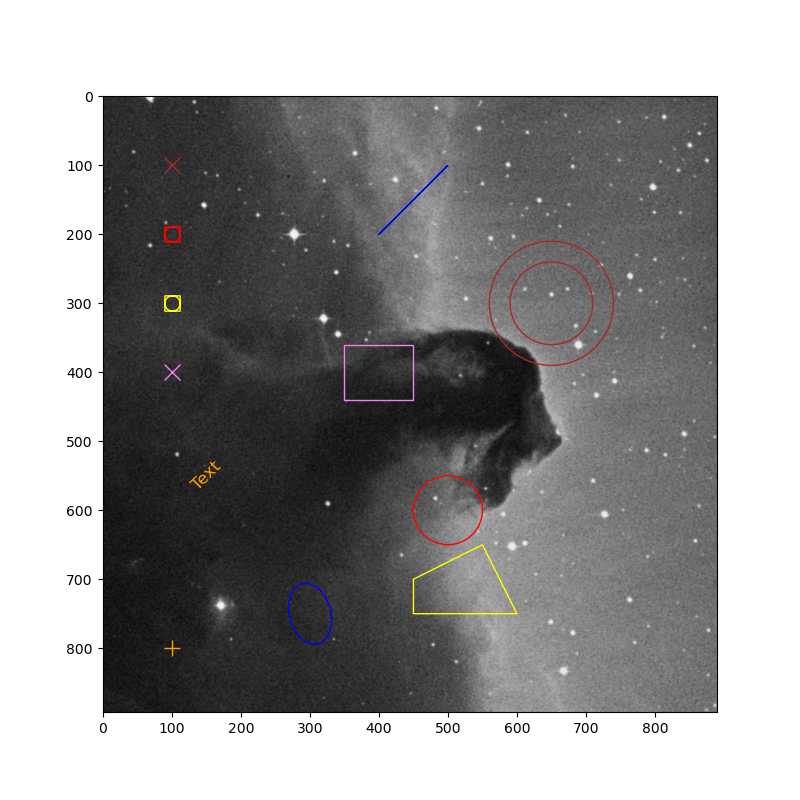

In [6]:
image_file = get_pkg_data_filename('tutorials/FITS-images/HorseHead.fits')
print(f"Downloaded HorseHead image file path is now {image_file}")
image_data = fits.getdata(image_file, ext=0, memmap=False)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image_data, cmap='gray')
#ax.set_ylim([-0.5, 892.5])

region_file = get_pkg_data_filename('data/plot_image.reg',
                                    package='regions.io.ds9.tests')
print(f"Downloaded regions.io.ds9.tests file path is now {region_file}")

regions = Regions.read(region_file, format='ds9')
for i, region in enumerate(regions):
    region.plot(ax=ax)

Input data 0.5th percentile = 5067.0000, 99.5th percentile = 16605.0000
Applying asinh stretch between 5067.0000 and 16605.0000
Using WCS information for axis projection
WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN' 
CRVAL : 85.59941666666666 -4.946638888888889 
CRPIX : -716.333144294269 -8444.64946698226 
PC1_1 PC1_2  : 0.015029018460682027 -9.63735777657198e-06 
PC2_1 PC2_2  : 1.0548917307845708e-05 0.015000473845055023 
CDELT : -0.018654788242111486 0.018654788242111486 
NAXIS : 891  893


Default X-axis limits: (np.float64(-0.5), np.float64(890.5))
Default Y-axis limits: (np.float64(-0.5), np.float64(892.5))


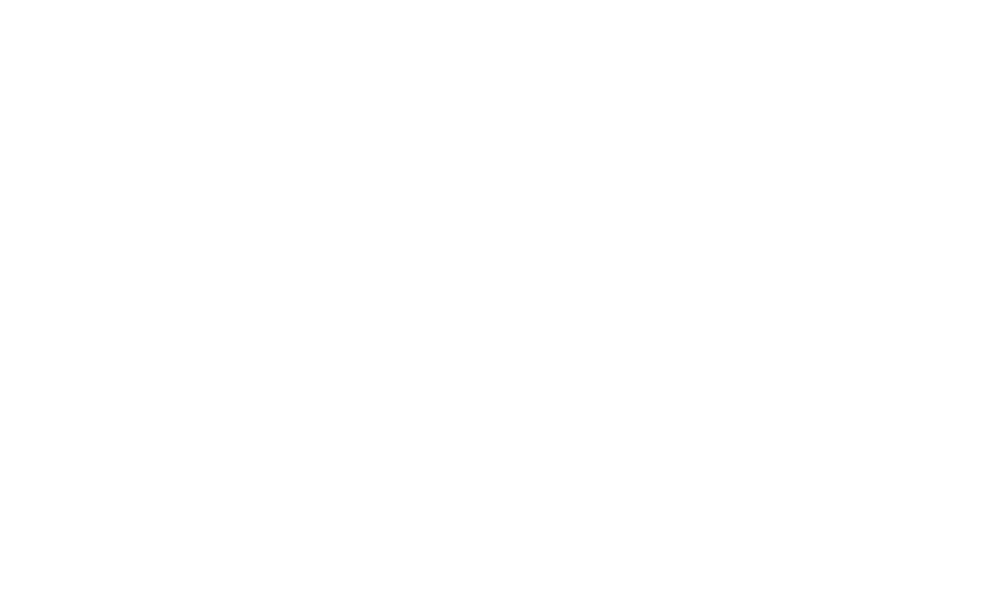

In [7]:
fig = plt.figure()
ap.util.load_image_and_plot(image_file)
plt.show()

There are a number of questions we need to address:

1. What actual format does the `ds9` region file have
2. Does this process match up to the origin is lower-lower convention we're used to from most astronomical images? Does it automatically adjust to the `origin`?
3. Does the regions package accept excluded regions, e.g. `-circle(10, 20, 5)`?
4. Can we read and plot RA, Dec, angular radius format file

### Question 1

The answer to question 1 is 
```bash
cat /home/dks/miniconda3/envs/ap-env/lib/python3.12/site-packages/regions/io/ds9/tests/data/plot_image.reg
# Region file format: DS9 astropy/regions
image
circle(501.000000,601.000000,50.000000) # color=red
line(401.000000,201.000000,501.000000,101.000000) # color=blue
point(101.000000,801.000000) # point=cross color=orange
point(101.000000,101.000000) # point=x color=brown
point(101.000000,301.000000) # point=boxcircle color=yellow
point(101.000000,401.000000) # point=x color=violet
point(101.000000,201.000000) # color=red
ellipse(301.000000,751.000000,45.000000,30.000000,75.000000) # color=blue
text(151.000000,551.000000) # text={Text} textangle=45 color=orange font="helvetica 12 normal roman"
annulus(651.000000,301.000000,60.000000,90.000000) # color=brown
polygon(451.000000,751.000000,451.000000,701.000000,551.000000,651.000000,601.000000,751.000000) # color=yellow
box(401.000000,401.000000,100.000000,80.000000,0.000000) # color=violet
```

### Question 2

Text(150.0, 550.0, 'Text')

findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.
findfont: Font family 'helvetica' not found.


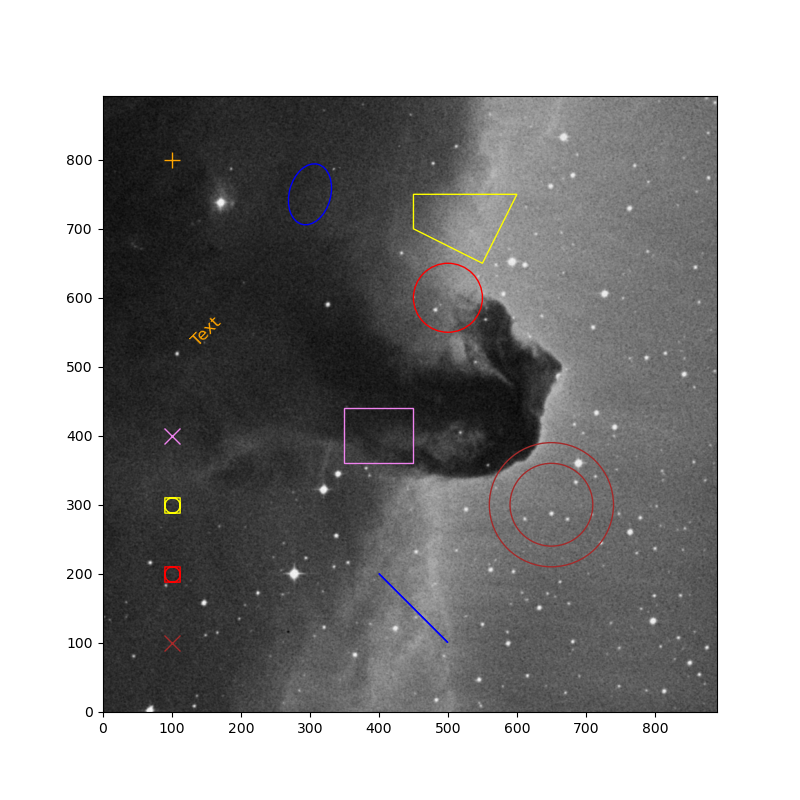

In [8]:

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(image_data, cmap='gray', origin='lower')

for i, region in enumerate(regions):
    region.plot(ax=ax)

# The answer is yes

### Question 3: Excluded regions

Attempt to load and plot the following pixel-based region file
```bash
cat dks_horsehead_test1.reg 
# Region file format: DS9 version 4.1
global color=green dashlist=8 3 width=1 select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1
physical
circle(326.62819,591.44465,12) # color=red test={s1}
circle(321.84624,323.09819,12) # color=red text={s2}
circle(338.69358,257.68477,9.9278981) # color=red text={s3}
circle(355.56271,214.82183,9.9278981) # color=red text={s4}
box(524.95529,486.40572,198.55796,397.11593,329.94194) # color=blue text={sky}
-circle(593.56468,653.28942,12) # color=yellow text={s5}
-circle(516.64286,406.43905,12) # color=yellow text={s6}
-circle(480.74295,584.62457,9.9279776) # color=yellow text={s7}
-circle(579.98686,605.94722,9.9278981) # color=yellow text={s8}
```

NAXIS    = 2
NAXIS1   = 893
NAXIS2   = 891
CTYPE1   = 'RA---TAN'
CTYPE2   = 'DEC--TAN'
CRVAL1   = 85.59941666666666
CRVAL2   = -4.946638888888889
CRPIX1   = -716.333144294269
CRPIX2   = -8444.64946698226
PC1_1    = 0.015029018460682027
PC1_2    = -9.63735777657198e-06
CDELT1   = -0.018654788242111486
PC2_1    = 1.0548917307845708e-05
PC2_2    = 0.015000473845055023
CDELT2   = 0.018654788242111486
CRVAL1,2 RA, Dec as HMS, DMS     = 05:42:23.9 -04:56:47.9
Pixel size equivalent CDELT1     = -1.007 arcseconds
Pixel size equivalent CDELT2     = 1.007 arcseconds
Image X-axis angular size        = -14.993 arcminutes
Pixel Y-axis angular size        = 14.960 arcminutes
Image rotation equivalent CROTA2 = -0.037 degrees
END     


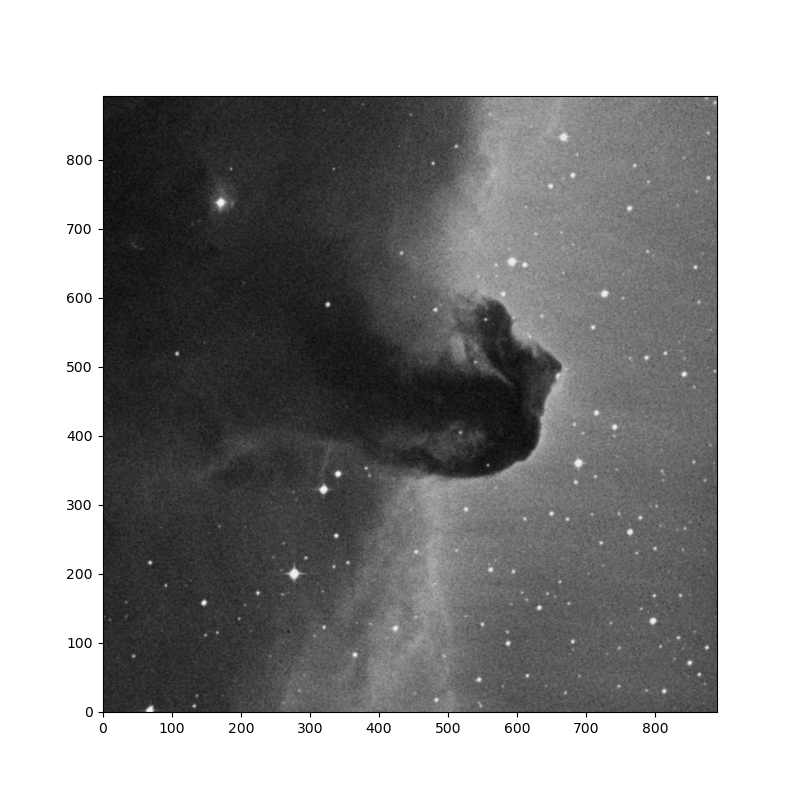

In [9]:
# Might as well star doing this more robustly too
region_file = '/old_lnx/home/dks/Downloads/iTelescopeScratch/T33/eta_car/dks_horsehead_test1.reg'
regions = Regions.read(region_file, format='ds9')

with fits.open(image_file, mode='readonly') as hdulist:
    image_data = hdulist[0].data
    image_hdr  = hdulist[0].header
    w = wcs.WCS(image_hdr)
    _ = ap.util.summarize_wcs(w)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image_data, cmap='gray', origin='lower')

    for i, region in enumerate(regions):
        region.plot(ax=ax)

*Argh!* It doesn't support `physical`. Try again with `image`.
```bash
cat dks_horsehead_test2.reg 
# Region file format: DS9 version 4.1
global color=green dashlist=8 3 width=1 font="helvetica 10 normal roman" select=1 highlite=1 dash=0 fixed=0 edit=1 move=1 delete=1 include=1 source=1
image
circle(326.62819,591.44465,12) # color=red text={s1}
circle(321.84624,323.09819,12) # color=red text={s2}
circle(338.69358,257.68477,9.9278981) # color=red text={s3}
circle(355.56271,214.82183,9.9278981) # color=red text={s4}
box(524.95529,486.40572,198.55796,397.11593,329.94194) # color=blue text={sky}
-circle(593.56468,653.28942,12) # color=yellow text={s5}
-circle(516.64286,406.43905,12) # color=yellow text={s6}
-circle(480.74295,584.62457,9.9279776) # color=yellow text={s7}
-circle(579.98686,605.94722,9.9278981) # color=yellow text={s8}

```

NAXIS    = 2
NAXIS1   = 893
NAXIS2   = 891
CTYPE1   = 'RA---TAN'
CTYPE2   = 'DEC--TAN'
CRVAL1   = 85.59941666666666
CRVAL2   = -4.946638888888889
CRPIX1   = -716.333144294269
CRPIX2   = -8444.64946698226
PC1_1    = 0.015029018460682027
PC1_2    = -9.63735777657198e-06
CDELT1   = -0.018654788242111486
PC2_1    = 1.0548917307845708e-05
PC2_2    = 0.015000473845055023
CDELT2   = 0.018654788242111486
CRVAL1,2 RA, Dec as HMS, DMS     = 05:42:23.9 -04:56:47.9
Pixel size equivalent CDELT1     = -1.007 arcseconds
Pixel size equivalent CDELT2     = 1.007 arcseconds
Image X-axis angular size        = -14.993 arcminutes
Pixel Y-axis angular size        = 14.960 arcminutes
Image rotation equivalent CROTA2 = -0.037 degrees
END     


Region 0 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 's1'}


Region 1 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 's2'}


Region 2 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 's3'}


Region 3 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 's4'}


Region 4 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 'sky'}


Region 5 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 0, 'source': 1, 'text': 's5'}


Region 6 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 0, 'source': 1, 'text': 's6'}


Region 7 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 0, 'source': 1, 'text': 's7'}


Region 8 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 0, 'source': 1, 'text': 's8'}


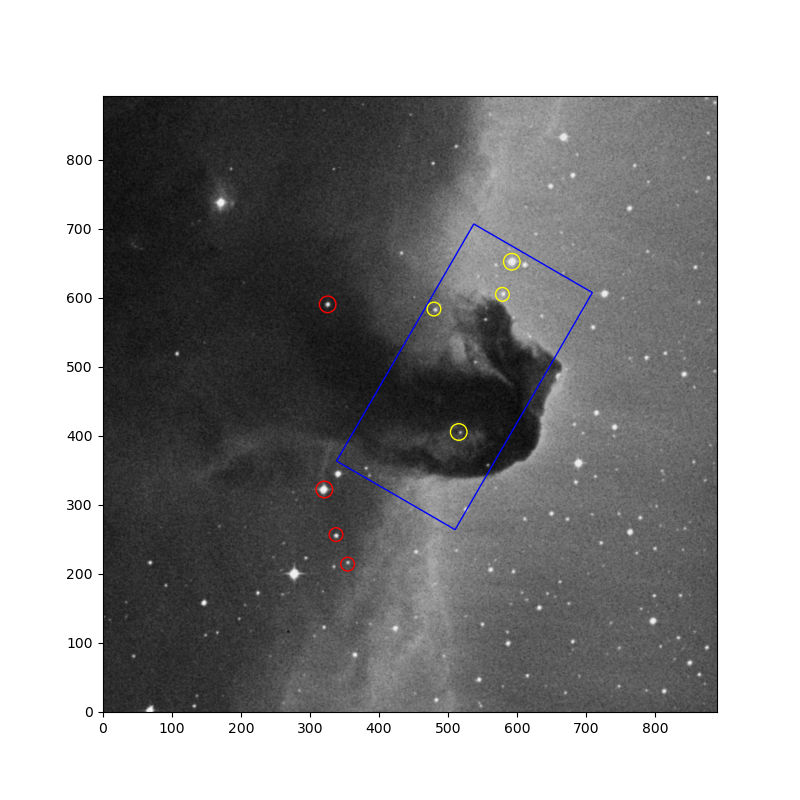

In [10]:
region_file = '/old_lnx/home/dks/Downloads/iTelescopeScratch/T33/eta_car/dks_horsehead_test2.reg'
regions = Regions.read(region_file, format='ds9')

with fits.open(image_file, mode='readonly') as hdulist:
    image_data = hdulist[0].data
    image_hdr  = hdulist[0].header
    w = wcs.WCS(image_hdr)
    _ = ap.util.summarize_wcs(w)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image_data, cmap='gray', origin='lower')

    for i, region in enumerate(regions):
        region.plot(ax=ax)
        print(f'Region {i} metadata is: {region.meta}')

### Question 4: Read and plot RA, Dec, format file

Here we may run into some issue with determining what `format` the regions package expects.

NAXIS    = 2
NAXIS1   = 893
NAXIS2   = 891
CTYPE1   = 'RA---TAN'
CTYPE2   = 'DEC--TAN'
CRVAL1   = 85.59941666666666
CRVAL2   = -4.946638888888889
CRPIX1   = -716.333144294269
CRPIX2   = -8444.64946698226
PC1_1    = 0.015029018460682027
PC1_2    = -9.63735777657198e-06
CDELT1   = -0.018654788242111486
PC2_1    = 1.0548917307845708e-05
PC2_2    = 0.015000473845055023
CDELT2   = 0.018654788242111486
CRVAL1,2 RA, Dec as HMS, DMS     = 05:42:23.9 -04:56:47.9
Pixel size equivalent CDELT1     = -1.007 arcseconds
Pixel size equivalent CDELT2     = 1.007 arcseconds
Image X-axis angular size        = -14.993 arcminutes
Pixel Y-axis angular size        = 14.960 arcminutes
Image rotation equivalent CROTA2 = -0.037 degrees
END     


Region 0 Region: CirclePixelRegion
center: PixCoord(x=325.6503693364847, y=590.4636965822865)
radius: 11.99988460184748 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 's1'}


Region 1 Region: CirclePixelRegion
center: PixCoord(x=320.86834450560355, y=322.11720438514203)
radius: 11.999799990234267 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 's2'}


Region 2 Region: CirclePixelRegion
center: PixCoord(x=337.7158723736878, y=256.7035804677198)
radius: 9.927840859620249 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 's3'}


Region 3 Region: CirclePixelRegion
center: PixCoord(x=354.5850553514445, y=213.8409184417833)
radius: 9.927831188844882 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 's4'}


Region 4 Region: RectanglePixelRegion
center: PixCoord(x=523.9775873121806, y=485.4247497569795)
width: 198.5582751335687
height: 397.1165502671374
angle: 329.94082143517255 deg metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 'sky'}


Region 5 Region: CirclePixelRegion
center: PixCoord(x=592.5869568542636, y=652.308332404351)
radius: 11.999929406642538 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 0, 'source': 1, 'text': 's5'}


Region 6 Region: CirclePixelRegion
center: PixCoord(x=515.6651666341037, y=405.4578423072853)
radius: 11.999843488967311 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 0, 'source': 1, 'text': 's6'}


Region 7 Region: CirclePixelRegion
center: PixCoord(x=479.76507660319146, y=583.6434442126665)
radius: 9.927935890757382 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 0, 'source': 1, 'text': 's7'}


Region 8 Region: CirclePixelRegion
center: PixCoord(x=579.0091326810046, y=604.9660638174337)
radius: 9.927949734398704 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 0, 'source': 1, 'text': 's8'}


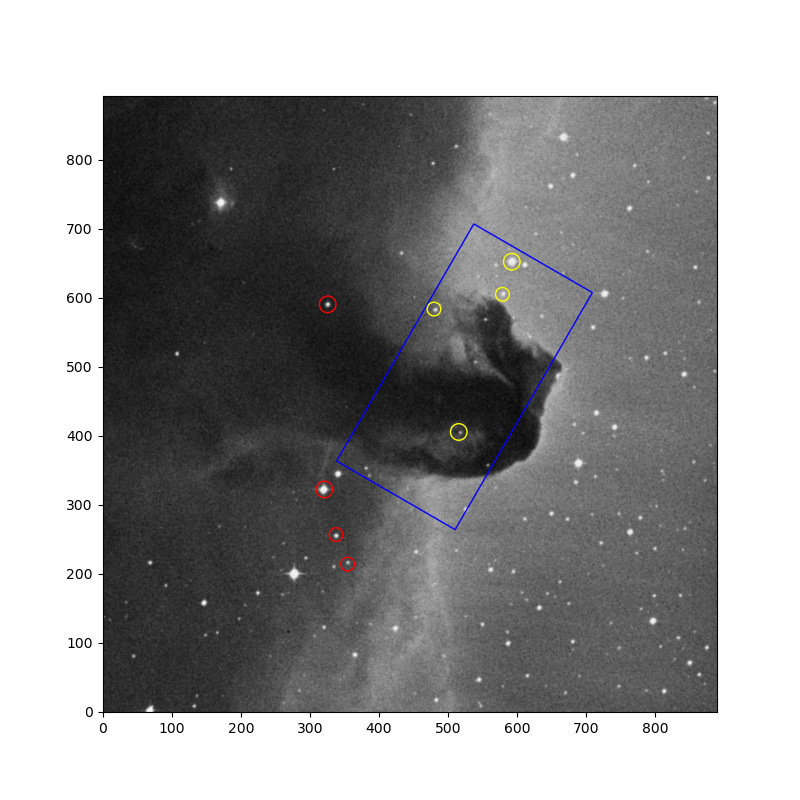

In [11]:
region_file = '/old_lnx/home/dks/Downloads/iTelescopeScratch/T33/eta_car/dks_horsehead_test3.reg'
regions = Regions.read(region_file, format='ds9')

with fits.open(image_file, mode='readonly') as hdulist:
    image_data = hdulist[0].data
    image_hdr  = hdulist[0].header
    w = wcs.WCS(image_hdr)
    _ = ap.util.summarize_wcs(w)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image_data, cmap='gray', origin='lower')

    for i, sky_region in enumerate(regions):
        region = sky_region.to_pixel(w)
        region.plot(ax=ax)
        print(f'Region {i} {region} metadata is: {region.meta}')

So the conversion appears correct, with only minor differences in converted radii from `ds9`. Those differences are likely consistent with the limited number of decimal places used in the ds9 region files.

## Masks, Statistics and Composite Region Building

It looks like `photutils` can uses `Regions`: https://photutils.readthedocs.io/en/2.2.0/api/photutils.aperture.aperture_photometry.html#photutils.aperture.aperture_photometry

### Masks

There are 9 defined regions
NAXIS    = 2
NAXIS1   = 893
NAXIS2   = 891
CTYPE1   = 'RA---TAN'
CTYPE2   = 'DEC--TAN'
CRVAL1   = 85.59941666666666
CRVAL2   = -4.946638888888889
CRPIX1   = -716.333144294269
CRPIX2   = -8444.64946698226
PC1_1    = 0.015029018460682027
PC1_2    = -9.63735777657198e-06
CDELT1   = -0.018654788242111486
PC2_1    = 1.0548917307845708e-05
PC2_2    = 0.015000473845055023
CDELT2   = 0.018654788242111486
CRVAL1,2 RA, Dec as HMS, DMS     = 05:42:23.9 -04:56:47.9
Pixel size equivalent CDELT1     = -1.007 arcseconds
Pixel size equivalent CDELT2     = 1.007 arcseconds
Image X-axis angular size        = -14.993 arcminutes
Pixel Y-axis angular size        = 14.960 arcminutes
Image rotation equivalent CROTA2 = -0.037 degrees
END     


Region 0 Region: CirclePixelRegion
center: PixCoord(x=325.62819, y=590.44465)
radius: 12.0 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 's1'}


Text(0.5, 1.0, 'Region 0')

Region 1 Region: CirclePixelRegion
center: PixCoord(x=320.84624, y=322.09819)
radius: 12.0 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 's2'}


Text(0.5, 1.0, 'Region 1')

...

Text(0.5, 1.0, 'Region 7')

Region 8 Region: CirclePixelRegion
center: PixCoord(x=578.98686, y=604.94722)
radius: 9.9278981 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 0, 'source': 1, 'text': 's8'}


Text(0.5, 1.0, 'Region 8')

Mega region Region: CompoundPixelRegion
region1: Region: CompoundPixelRegion
region1: Region: CompoundPixelRegion
region1: Region: CompoundPixelRegion
region1: Region: CompoundPixelRegion
region1: Region: CompoundPixelRegion
region1: Region: RectanglePixelRegion
center: PixCoord(x=523.95529, y=485.40572)
width: 198.55796
height: 397.11593
angle: 329.94194 deg
region2: Region: CirclePixelRegion
center: PixCoord(x=592.56468, y=652.28942)
radius: 12.0
operator: <built-in function xor>
region2: Region: CirclePixelRegion
center: PixCoord(x=515.64286, y=405.43905)
radius: 12.0
operator: <built-in function xor>
region2: Region: CirclePixelRegion
center: PixCoord(x=479.74295, y=583.62457)
radius: 9.9279776
operator: <built-in function xor>
region2: Region: CirclePixelRegion
center: PixCoord(x=578.98686, y=604.94722)
radius: 9.9278981
operator: <built-in function xor>
region2: Region: CirclePixelRegion
center: PixCoord(x=320.84624, y=322.09819)
radius: 12.0
operator: <built-in function xor>
reg

Text(0.5, 1.0, 'Mega region')

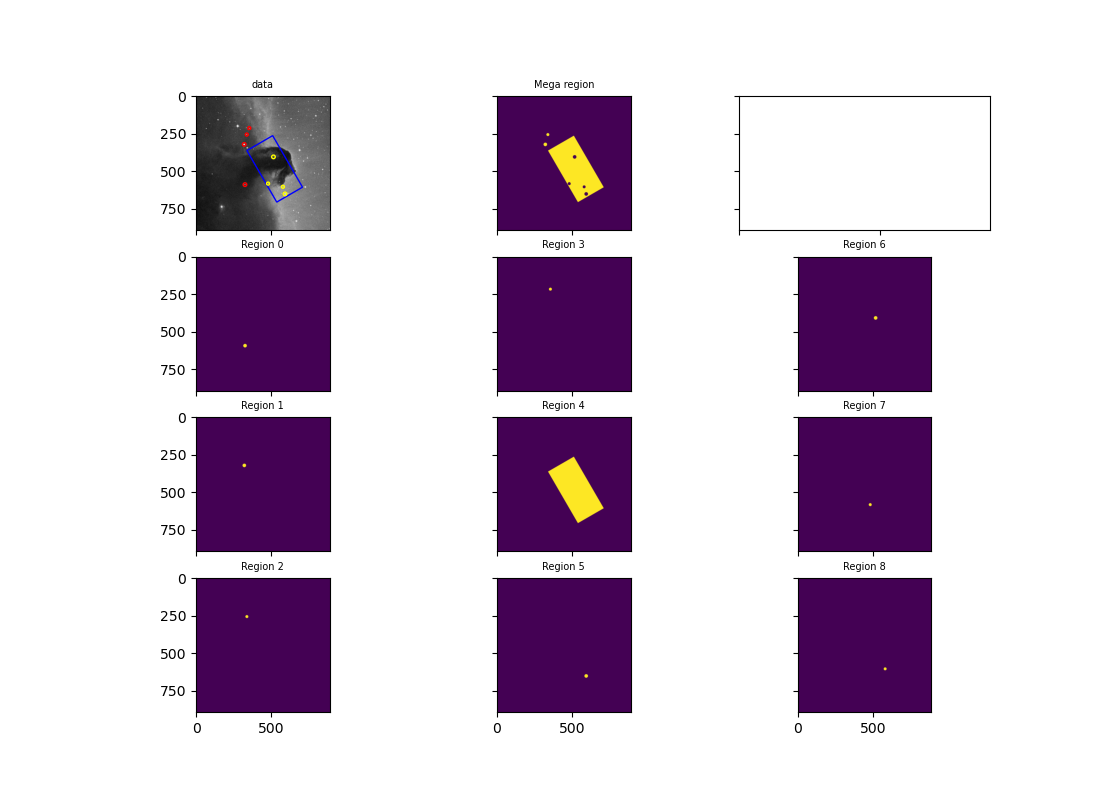

In [12]:
region_file = '/old_lnx/home/dks/Downloads/iTelescopeScratch/T33/eta_car/dks_horsehead_test2.reg'
regions = Regions.read(region_file, format='ds9')
print(f'There are {len(regions)} defined regions')
fig, axarr = plt.subplots(nrows=4, ncols=3, figsize=(11, 8), sharex=True, sharey=True)

baseax = axarr[0][0]
baseax.imshow(image_data, cmap='gray', origin='lower')
baseax.set_title('data', fontsize=7)

# make a composite mask that is the exclusive or of the masks

with fits.open(image_file, mode='readonly') as hdulist:
    image_data = hdulist[0].data
    image_hdr  = hdulist[0].header
    w = wcs.WCS(image_hdr)
    _ = ap.util.summarize_wcs(w)

    mega_reg = None
    
    rlist = []
    for i, region in enumerate(regions):
        #region = sky_region.to_pixel(w)
        region.plot(ax=baseax)
        print(f'Region {i} {region} metadata is: {region.meta}')

        mask = region.to_mask(mode='center')
        a = (i)%3
        b = (i)//3
        #print(a, b)
        axarr[a+1][b].imshow(mask.to_image(image_data.shape))
        axarr[a+1][b].set_title(f'Region {i}', fontsize=7)

        if i >= 4:
            if mega_reg is None:
                mega_reg = region
            else:
                mega_reg = mega_reg.symmetric_difference(region)

    # see what happens if we include some of the earlier ones.
    for idx in [1, 2]:
        mega_reg = mega_reg.symmetric_difference(regions[idx])
    
    print(f'Mega region {mega_reg} metadata is: {mega_reg.meta}')
    mask = mega_reg.to_mask(mode='center')
    a=0
    b=1
    axarr[a][b].imshow(mask.to_image(image_data.shape))
    axarr[a][b].set_title(f'Mega region', fontsize=7)


For stars within the rectangle that appears reasonable, but anything outside is included rather than excluded. And in this case we do not have any stars straddling the boundary of the rectangle, which would be a likely case in a real situation.

Overall this is insufficient.

### Aperture photometry

NAXIS    = 2
NAXIS1   = 893
NAXIS2   = 891
CTYPE1   = 'RA---TAN'
CTYPE2   = 'DEC--TAN'
CRVAL1   = 85.59941666666666
CRVAL2   = -4.946638888888889
CRPIX1   = -716.333144294269
CRPIX2   = -8444.64946698226
PC1_1    = 0.015029018460682027
PC1_2    = -9.63735777657198e-06
CDELT1   = -0.018654788242111486
PC2_1    = 1.0548917307845708e-05
PC2_2    = 0.015000473845055023
CDELT2   = 0.018654788242111486
CRVAL1,2 RA, Dec as HMS, DMS     = 05:42:23.9 -04:56:47.9
Pixel size equivalent CDELT1     = -1.007 arcseconds
Pixel size equivalent CDELT2     = 1.007 arcseconds
Image X-axis angular size        = -14.993 arcminutes
Pixel Y-axis angular size        = 14.960 arcminutes
Image rotation equivalent CROTA2 = -0.037 degrees
END     


Region 0 Region: CirclePixelRegion
center: PixCoord(x=325.62819, y=590.44465)
radius: 12.0 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 's1'}
About to perform aperture photometry on region 0
 id  xcenter   ycenter     aperture_sum   
--- --------- --------- ------------------
  1 325.62819 590.44465 3388535.6781131774


Region 1 Region: CirclePixelRegion
center: PixCoord(x=320.84624, y=322.09819)
radius: 12.0 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 's2'}
About to perform aperture photometry on region 1
 id  xcenter   ycenter     aperture_sum  
--- --------- --------- -----------------
  1 320.84624 322.09819 5477693.985043209


Region 2 Region: CirclePixelRegion
center: PixCoord(x=337.69358, y=256.68477)
radius: 9.9278981 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 's3'}
About to perform aperture photometry on region 2
 id  xcenter   ycenter     aperture_sum   
--- --------- --------- ------------------
  1 337.69358 256.68477 3024087.4739615824


Region 3 Region: CirclePixelRegion
center: PixCoord(x=354.56271, y=213.82183)
radius: 9.9278981 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 's4'}
About to perform aperture photometry on region 3
 id  xcenter   ycenter     aperture_sum  
--- --------- --------- -----------------
  1 354.56271 213.82183 3077242.835226465


Region 4 Region: RectanglePixelRegion
center: PixCoord(x=523.95529, y=485.40572)
width: 198.55796
height: 397.11593
angle: 329.94194 deg metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 1, 'source': 1, 'text': 'sky'}
About to perform aperture photometry on region 4
 id  xcenter   ycenter     aperture_sum  
--- --------- --------- -----------------
  1 523.95529 485.40572 786564527.8759766


Region 5 Region: CirclePixelRegion
center: PixCoord(x=592.56468, y=652.28942)
radius: 12.0 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 0, 'source': 1, 'text': 's5'}
About to perform aperture photometry on region 5
 id  xcenter   ycenter     aperture_sum  
--- --------- --------- -----------------
  1 592.56468 652.28942 7562138.152545676


Region 6 Region: CirclePixelRegion
center: PixCoord(x=515.64286, y=405.43905)
radius: 12.0 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 0, 'source': 1, 'text': 's6'}
About to perform aperture photometry on region 6
 id  xcenter   ycenter     aperture_sum   
--- --------- --------- ------------------
  1 515.64286 405.43905 3799484.1708591143


Region 7 Region: CirclePixelRegion
center: PixCoord(x=479.74295, y=583.62457)
radius: 9.9279776 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 0, 'source': 1, 'text': 's7'}
About to perform aperture photometry on region 7
 id  xcenter   ycenter     aperture_sum  
--- --------- --------- -----------------
  1 479.74295 583.62457 3742381.044096103


Region 8 Region: CirclePixelRegion
center: PixCoord(x=578.98686, y=604.94722)
radius: 9.9278981 metadata is: {'select': 1, 'highlite': 1, 'fixed': 0, 'edit': 1, 'move': 1, 'delete': 1, 'include': 0, 'source': 1, 'text': 's8'}
About to perform aperture photometry on region 8
 id  xcenter   ycenter     aperture_sum  
--- --------- --------- -----------------
  1 578.98686 604.94722 4990568.072650727


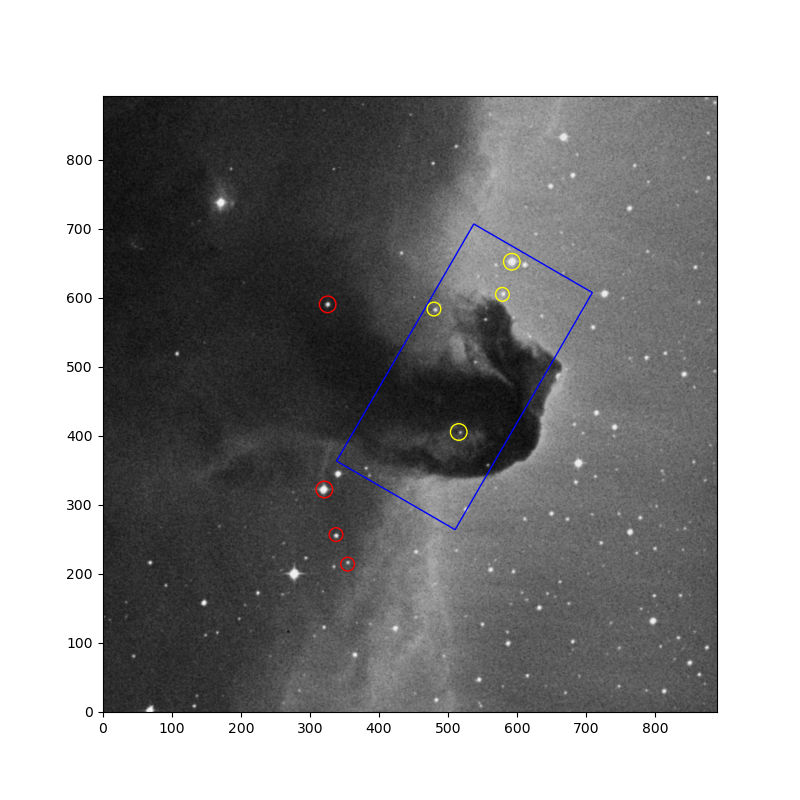

In [13]:
region_file = '/old_lnx/home/dks/Downloads/iTelescopeScratch/T33/eta_car/dks_horsehead_test2.reg'
regions = Regions.read(region_file, format='ds9')

with fits.open(image_file, mode='readonly') as hdulist:
    image_data = hdulist[0].data
    image_hdr  = hdulist[0].header
    w = wcs.WCS(image_hdr)
    _ = ap.util.summarize_wcs(w)

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(image_data, cmap='gray', origin='lower')

    rlist = []
    for i, region in enumerate(regions):
        #region = sky_region.to_pixel(w)
        region.plot(ax=ax)
        print(f'Region {i} {region} metadata is: {region.meta}')
        rlist.append( region )

        print(f'About to perform aperture photometry on region {i}')
        out = aperture_photometry(image_data, apertures=region, method='exact')
        out.pprint_all()
    
    #print('About to perform aperture photometry...')
    #out = aperture_photometry(image_data, apertures=rlist, method='exact')
    #out.pprint_all()

# Versions and Changes

| Version | Date | Description |
|:--------|------|-------------|
| version        | date | Initial version |

In [14]:
# close all the figures
plt.close('all')